# (27) BALLS: Test

project = ```iP-VAE```, host = ```yoru```, device = ```cuda:0```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from base.helper import find_weight_concentrations
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## poisson

In [3]:
model_name = 'poisson_BALLS16_t-16_z-[32]_cl-10,10_<grad|lin>'
fit_name = 'b400-ep2000-lr(0.002)_beta(8:0.1)_temp(0.01:0.5)_gr(5000)_(2025_02_28,09:13)'

tr, meta = load_model(f"{model_name}/{fit_name}", device)
print(meta)

{
    'timestamp': '2025_02_28,09:13',
    'checkpoint': 2000,
    'global_step': 300000,
    'root': 
'/home/hadi/Projects/PoissonVAE/models/poisson_BALLS16_t-16_z-[32]_cl-10,10_<grad|lin>/b400-ep2000-lr(0.002)_beta(8
:0.1)_temp(0.01:0.5)_gr(5000)_(2025_02_28,09:13)',
    'file': 'IPVAE+Trainer-2000_(2025_02_28,12:45).pt'
}

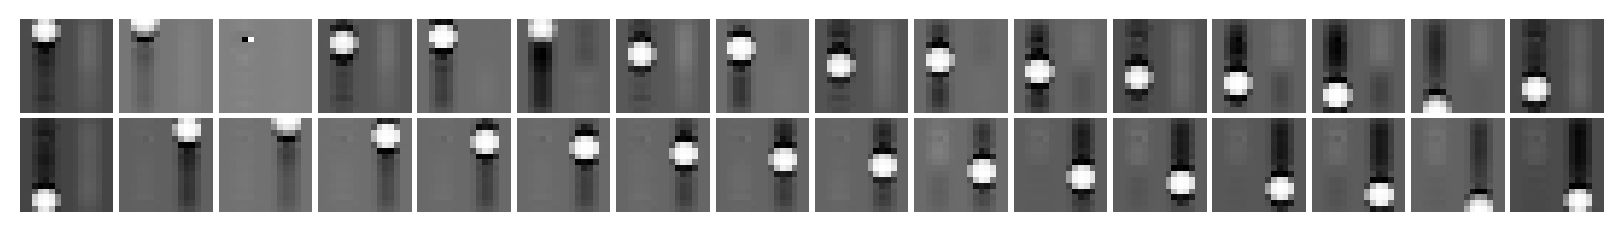

In [4]:
w = tr.model.layer.get_weight()
w = tonp(w.T).reshape(32, 16, 16)
ordered_indices, centers = find_weight_concentrations(
    w, lambda p: p[0] + (p[1] > 6).astype(float) * 50)

tr.model.show(order=ordered_indices, nrows=2);

100%|███████████████████████████████████| 5/5 [00:09<00:00,  1.95s/it]


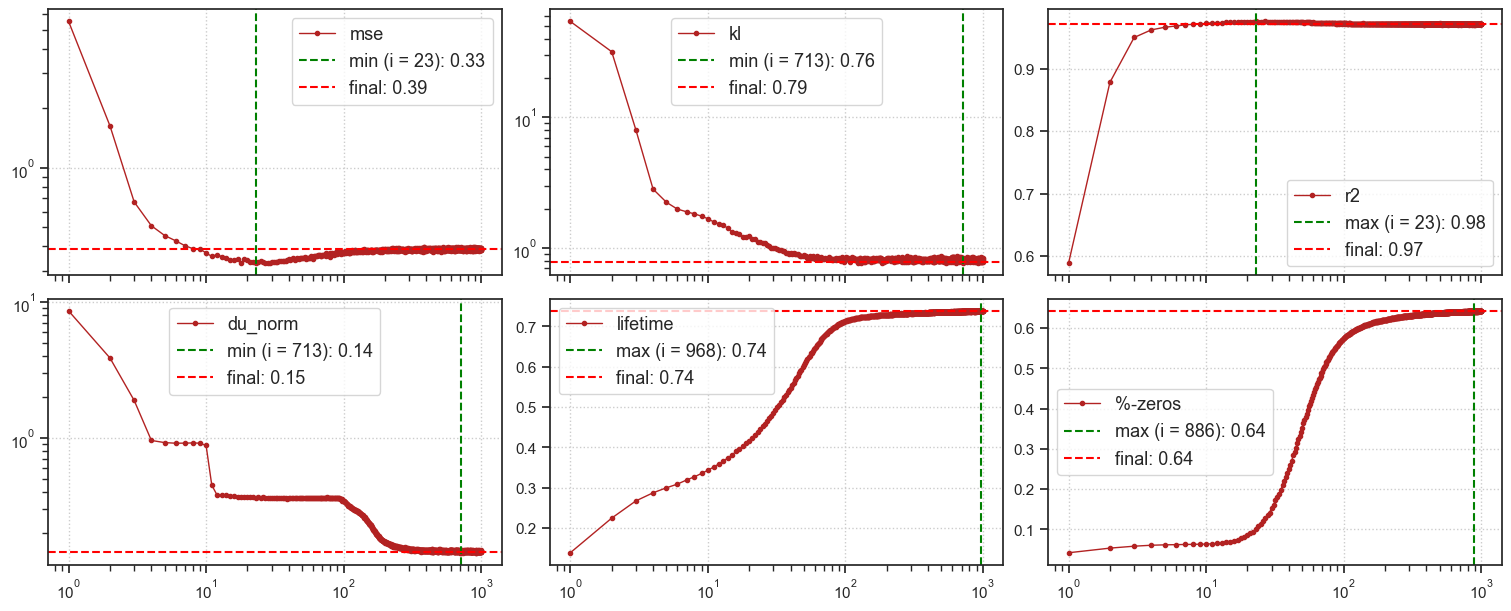

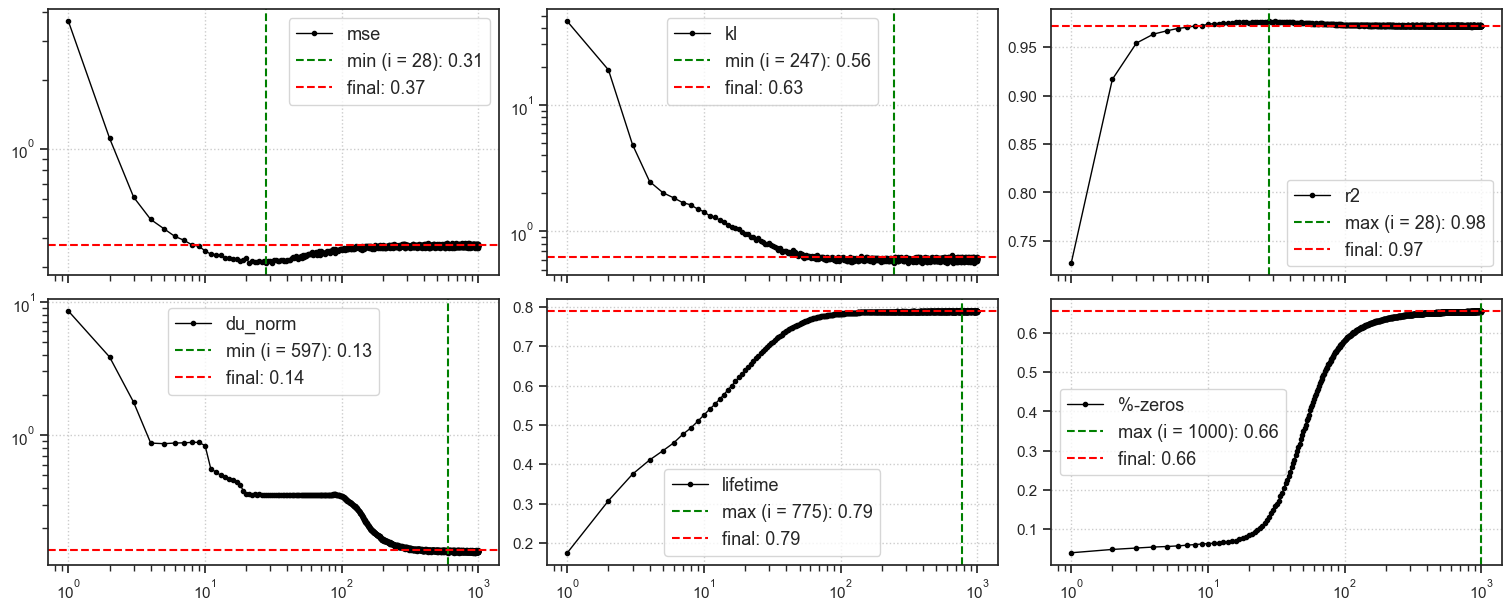

CPU times: user 23 s, sys: 235 ms, total: 23.2 s
Wall time: 23.2 s


In [5]:
%%time

kws = dict(
    seq_total=1000,
    seq_batch_sz=1000,
    n_data_batches=5,
)
results = {
    k: tr.analysis(k, **kws)
    for k in ['tst', 'vld']
}
# plot
_ = plot_convergence(results['tst'], color='firebrick')
_ = plot_convergence(results['vld'], color='k')

In [6]:
%%time


seq_total = 1000
selection = ['u', 'samples', 'r2']

kws_dl = dict(
    batch_size=1000,
    drop_last=False,
    shuffle=False,
)

results = {}
for item in ['trn', 'vld', 'tst']:
    # create data loader without shuffle
    ds = getattr(tr, f"dl_{item}").dataset
    dl = torch.utils.data.DataLoader(ds, **kws_dl)
    data = collections.defaultdict(list)
    for x, g in tqdm(iter(dl)):
        output = tr.model.xtract_ftr(
            feeder=tr.get_feeder(x),
            seq=range(seq_total),
            return_extras=True,
        ).stack()
        data['g'].append(g)
        for key in selection:
            data[key].append(output[key][:, -1])
        data['lamb'].append(output['u'][:, -1].exp())
    data = {
        k: tonp(torch.cat(v)) for
        k, v in data.items()
    }
    results[item] = data

100%|███████████████████████████████████████████| 50/50 [01:38<00:00,  1.97s/it]

CPU times: user 4min 16s, sys: 212 ms, total: 4min 16s
Wall time: 4min 16s


In [8]:
list(results['trn'])

['g', 'u', 'samples', 'r2', 'lamb']

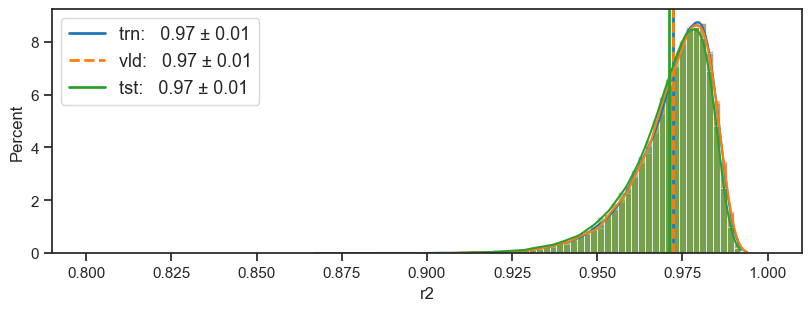

In [9]:
fig, ax = create_figure(1, 1, (8, 3))
for i, (name, d) in enumerate(results.items()):
    sns.histplot(d['r2'], stat='percent', kde=True, bins=np.linspace(0.8, 1.0, 101), color=f"C{i}", ax=ax)
    _a = d['r2'].mean()
    _s = d['r2'].std()
    ls = '--' if name == 'vld' else '-'
    ax.axvline(_a, ls=ls, lw=2, color=f"C{i}", label=f"{name}:   {_a:0.2f} ± {_s:0.2f}")
ax.legend(fontsize=13)
ax.set_xlabel('r2')
plt.show()

In [10]:
var = 'lamb'

lr = LinearRegression().fit(
    X=results['trn'][var],
    y=results['trn']['g'][:, [1, 3]],
)
r2 = {
    name: r2_score(
        y_true=d['g'][:, [1, 3]],
        y_pred=lr.predict(d[var]),
        multioutput='raw_values')
    for name, d in results.items()
}
corr = {
    name: 1 - np.diag(sp_dist.cdist(
        XA=d['g'][:, [1, 3]].T,
        XB=lr.predict(d[var]).T,
        metric='correlation',
    )) for name, d in results.items()
}

In [11]:
print(f"r2:", r2, '\nCorr:', corr)

r2:
{
    'trn': array([0.9952084 , 0.99529946], dtype=float32),
    'vld': array([0.99528456, 0.9952179 ], dtype=float32),
    'tst': array([0.96924424, 0.9681348 ], dtype=float32)
}

Corr:
{
    'trn': array([0.99760128, 0.99764693]),
    'vld': array([0.99763961, 0.99760648]),
    'tst': array([0.98492225, 0.98454898])
}

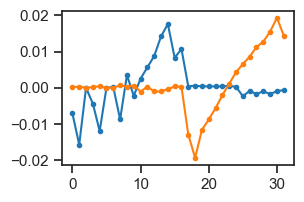

In [12]:
plot(lr.coef_.T[ordered_indices], marker='.')
plt.show()

## Plot spks

In [13]:
feeder = tr.get_feeder()

output = tr.model.xtract_ftr(
    feeder=feeder,
    seq=range(1000),
    return_extras=True,
).stack()

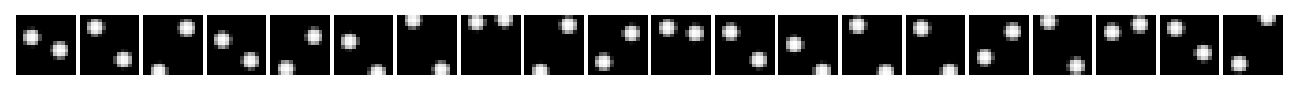

In [14]:
plot_weights(feeder.x[:20], nrows=1);

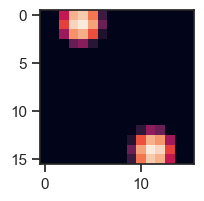

In [15]:
stim_i = 6
imshow(feeder.x[stim_i])
plt.show()

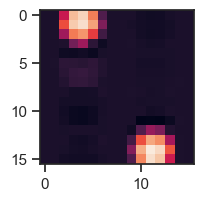

In [16]:
recon = output['recon'][stim_i, -1]
imshow(recon.reshape(16, 16))
plt.show()

In [17]:
output['r2'][stim_i, -1]

tensor(0.9874, device='cuda:0')

In [18]:
spks = output['samples'][stim_i, -1]
spks

tensor([  0.,  54.,   0.,   0.,   0.,   0., 177.,  23.,   0.,   0.,   0.,   0.,
         64.,   0.,  29.,   0.,  36.,   0.,   0.,   0.,   0.,  78.,  37.,   0.,
          0.,   0.,   0., 118.,  21.,   0.,   0.,   0.], device='cuda:0')

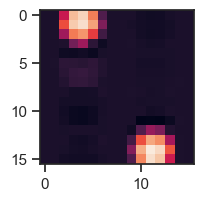

In [19]:
y = tr.model.layer.phi(spks)
imshow(y.reshape(16, 16))
plt.show()

In [20]:
spks[ordered_indices]

tensor([177.,  64.,   0.,  29.,   0.,   0.,  54.,   0.,  37.,   0.,   0.,  21.,
          0.,   0.,   0.,  23.,  36.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,  78., 118.], device='cuda:0')

In [21]:
np.linalg.norm(w, axis=(1, 2))

array([0.0219565 , 0.01441995, 0.02325934, 0.02273526, 0.02293854,
       0.01972787, 0.01356497, 0.01422468, 0.02662143, 0.3253057 ,
       0.02230288, 0.06050758, 0.01871677, 0.01935165, 0.01658762,
       0.01563908, 0.01284051, 0.02106028, 0.02180001, 0.02310291,
       0.0257154 , 0.01593166, 0.01492542, 0.01987798, 0.02134339,
       0.01916241, 0.02427809, 0.01586949, 0.01436112, 0.02289922,
       0.01967102, 0.02406585], dtype=float32)

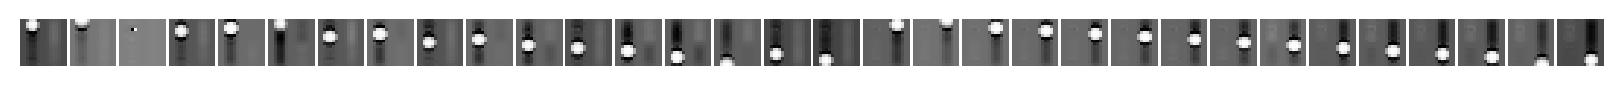

In [22]:
tr.model.show(order=ordered_indices, nrows=1);

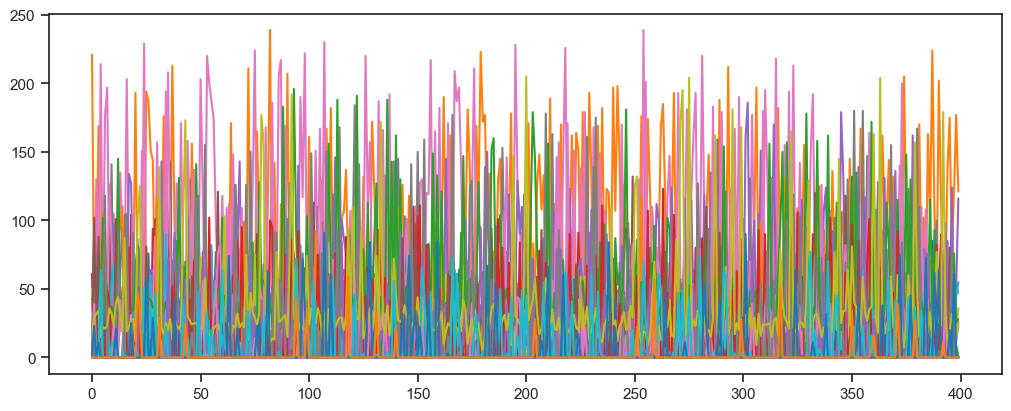

In [29]:
_ = create_figure(1, 1, (10, 4))
plot(output['samples'][:, -1, :])
plt.show()